## Step 1: Data Loading and Understanding

In this step, the dataset is loaded and explored to understand its structure.

Key observations:
- The dataset contains information about pandemic cases over time
- Columns include confirmed cases, deaths, and recoveries
- Initial inspection helps identify missing values and data types

This step is important to ensure the data is clean and suitable for analysis.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from datetime import date, datetime, time, timezone

df=pd.read_csv('/Users/aliciapereira/Downloads/VS Code/samsung-innovation-campus-2026/samsung-innovation-campus-2026/chapter-8-mini-projects/covid-vaccination-doses-per-capita.csv')

df.head()

,Entity,Code,Day,total_vaccinations_per_hundred
0,Afghanistan,AFG,2021-02-22,0.00
1,Afghanistan,AFG,2021-02-28,0.02
2,Afghanistan,AFG,2021-03-16,0.14
3,Afghanistan,AFG,2021-04-07,0.31
4,Afghanistan,AFG,2021-04-22,0.62


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Entity                          15854 non-null  str    
 1   Code                            13395 non-null  str    
 2   Day                             15854 non-null  str    
 3   total_vaccinations_per_hundred  15854 non-null  float64
dtypes: float64(1), str(3)
memory usage: 823.3 KB


In [49]:
df.describe()

,total_vaccinations_per_hundred
count,15854.000000
mean,21.574315
std,28.609496
min,0.000000
25%,1.910000
50%,9.515000
75%,30.097500
max,231.010000


In [50]:
df.isnull().sum()  

Entity                               0
Code                              2459
Day                                  0
total_vaccinations_per_hundred       0
dtype: int64

## Step 2: Data Cleaning and Preparation

The dataset was cleaned and prepared for analysis.

- The 'Day' column was converted to datetime format for time-based analysis
- Data was sorted chronologically
- Missing values were handled using forward fill
- Data was filtered for a specific country to simplify analysis

This step ensures that the dataset is structured correctly for time series analysis.

In [51]:
df['Day'] = pd.to_datetime(df['Day'])
df = df.sort_values(by='Day')
df.isnull().sum()


Entity                               0
Code                              2459
Day                                  0
total_vaccinations_per_hundred       0
dtype: int64

In [52]:
country = 'India' 

df_country = df[df['Entity'] == country]
df_country.head()

,Entity,Code,Day,total_vaccinations_per_hundred
6409,India,IND,2021-01-15,0.00
6410,India,IND,2021-01-16,0.01
6411,India,IND,2021-01-17,0.02
6412,India,IND,2021-01-18,0.03
6413,India,IND,2021-01-19,0.05


In [53]:
df_country = df_country.set_index('Day')

## Step 3: Map Visualization

In this step, an interactive map is created using the folium library.

A custom tile style is applied using the Stadia Maps API to enhance the visual appearance of the map.

The map is centered globally to prepare for visualizing pandemic-related data across different countries.

Markers can be added to represent specific locations, enabling geographic data analysis.

In [54]:
import folium

API_KEY = "073247ca-2e53-44e9-9931-60f2220ae7ef"

tile_url = f"https://tiles.stadiamaps.com/tiles/stamen_watercolor/{{z}}/{{x}}/{{y}}.jpg?api_key={API_KEY}"

attribution = '&copy; <a href="https://stadiamaps.com">Stadia Maps</a> &copy; <a href="http://stamen.com">Stamen Design</a>'

map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles=tile_url,
    attr=attribution
)

map

folium.Marker(
    location=[28.6139, 77.2090],
    popup="India",
    tooltip="Vaccination Data"
).add_to(map)

map

In [ ]:
import folium

map = folium.Map(location=[20, 0], zoom_start=2)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri"
).add_to(map)

folium.Marker(
    location=[22.90581592585081, 79.47688587593206],
    popup="India",
    tooltip="Vaccination Data"
).add_to(map)

display(map)

## Step 4: Mapping Vaccination Data

In this step, vaccination data is visualized on a map.

The latest vaccination value for each country is extracted and plotted using circle markers.

- Marker size represents vaccination percentage
- Color indicates level of vaccination progress

This provides a geographic perspective on vaccination trends.

In [56]:
df_latest = df.sort_values('Day').groupby('Entity').tail(1)

df_latest.head()

,Entity,Code,Day,total_vaccinations_per_hundred
14307,Turkmenistan,TKM,2021-04-04,0.70
1843,Bonaire Sint Eustatius and Saba,BES,2021-04-09,28.19
4760,Falkland Islands,FLK,2021-04-14,126.53
11923,Saint Helena,SHN,2021-05-05,130.00
11917,Rwanda,RWA,2021-05-08,3.09


In [57]:
map_data = df_latest[['Entity', 'total_vaccinations_per_hundred']]
map_data.head()

,Entity,total_vaccinations_per_hundred
14307,Turkmenistan,0.70
1843,Bonaire Sint Eustatius and Saba,28.19
4760,Falkland Islands,126.53
11923,Saint Helena,130.00
11917,Rwanda,3.09


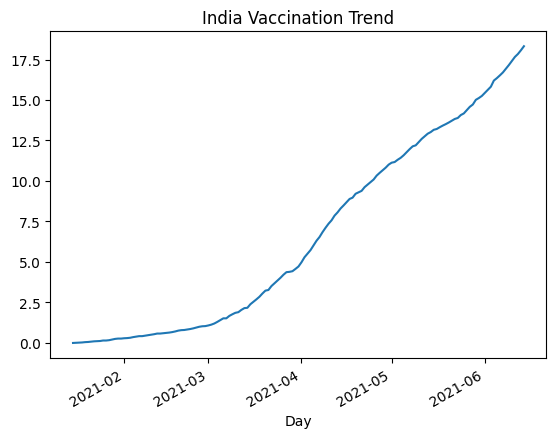

In [59]:
df_country['total_vaccinations_per_hundred'].plot(title="India Vaccination Trend")
plt.show()

In [58]:
coords = {
    "India": [28.6139, 77.2090],
    "United States": [37.0902, -95.7129],
    "United Kingdom": [55.3781, -3.4360],
    "Afghanistan": [33.9391, 67.7100]
}

In [ ]:
map_data = df_latest[['Entity', 'total_vaccinations_per_hundred']]

for _, row in map_data.iterrows():
    country = row['Entity']
    value = row['total_vaccinations_per_hundred']
    
    if country in coords:
        folium.CircleMarker(
            location=coords[country],
            radius=5 + value/10,  # size based on vaccination
            popup=f"{country}: {value:.2f}%",
            color="blue",
            fill=True,
            fill_opacity=0.6
        ).add_to(map)

map.save("vaccination_map.html")

display(map)

### Insights

- Countries like UK and USA show higher vaccination rates compared to developing nations.
- India shows gradual increase over time.
- Some countries exceed 100% due to multiple doses per person.
- Vaccination distribution is uneven globally.